In [1]:
import numpy as np

from enterprise_warp import enterprise_warp

from PTMCMCSampler.PTMCMCSampler import PTSampler as ptmcmc
# ─── Monkey-patch EntryPoint.default_kwargs ────────────────────────────────────
try:
    import entrypoints
    entrypoints.EntryPoint.default_kwargs = property(
        lambda self: getattr(self.load(), "__kwdefaults__", {}) or {}
    )
except ImportError:
    pass

try:
    # In case enterprise_warp is using importlib.metadata.EntryPoint instead
    import importlib.metadata as _im
    _im.EntryPoint.default_kwargs = property(
        lambda self: getattr(self.load(), "__kwdefaults__", {}) or {}
    )
except (ImportError, AttributeError):
    pass
# ────────────────────────────────────────────────────────────────────────────────

MPI startup(): FI_PSM3_UUID was not generated, please set it to avoid possible resources ownership conflicts between MPI processes
Optional acor package is not installed. Acor is optionally used to calculate the effective chain length for output in the chain file.


In [2]:
import sys
import ppta_dr2_models


#"gwb": "pol_dist_10_nfreqs"
# keep only the script name
sys.argv = sys.argv[:1]

path_par = "/fred/oz103/ezahraoui/PPTA/run_warp/sampling_params/2_psr_test_joint.dat"
#path_par = "/fred/oz103/ezahraoui/PPTA/run_wrap/sampling_params/ppta_dr2_vanilla_curn_full_param.dat"
#opts = enterprise_warp.parse_commandline()
opts = enterprise_warp.parse_commandline()

custom = ppta_dr2_models.PPTADR2Models



In [3]:
#"pol_dist_5_nfreqs" : 
params = enterprise_warp.Params(path_par,opts=opts,custom_models_obj=custom)


------------------
Setting default parameters with file  /fred/oz103/ezahraoui/PPTA/run_warp/sampling_params/2_psr_test_joint.dat
Setting default Solar System Ephemeris: DE438
Only using pulsars from psrlist
Setting a default linear timing model
Setting timing model SVD to 0 (False)
Including transient events to specific pulsar models
Setting reference radio frequency to 1400 MHz
------------------
Setting sampler kwargs from the parameter file:
------------------
Number of .par files:  25
Number of .tim files:  25
Loading pulsars
[tempo2Util.C:396] Warning: [TIM1] Please place MODE flags in the parameter file 


Pol calibration is set to True
Adding polynomial distortion vec to pulsars


In [4]:
pta = enterprise_warp.init_pta(params)
print('Pulsar Timing Array: ', len(pta))


Using noise parameters from the file:  {'J1017-7156_CASPSR_40CM_efac': 0.9500898591476656, 'J1017-7156_CASPSR_40CM_log10_ecorr': -6.2238211401001875, 'J1017-7156_CASPSR_40CM_log10_equad': -7.863228590651094, 'J1017-7156_PDFB_10CM_efac': 0.9218148778824311, 'J1017-7156_PDFB_10CM_log10_ecorr': -6.449274392564142, 'J1017-7156_PDFB_10CM_log10_equad': -7.591492002018053, 'J1017-7156_PDFB_20CM_efac': 1.0316646647950565, 'J1017-7156_PDFB_20CM_log10_ecorr': -6.975378830809108, 'J1017-7156_PDFB_20CM_log10_equad': -7.179888699936217, 'J1017-7156_PDFB_40CM_efac': 1.0147655457736018, 'J1017-7156_PDFB_40CM_log10_ecorr': -6.303308193083504, 'J1017-7156_PDFB_40CM_log10_equad': -7.266211196225819, 'J1017-7156_chromatic_gp_gamma': 3.204108597679067, 'J1017-7156_chromatic_gp_log10_A': -12.95722626873605, 'J1017-7156_red_noise_gamma': 3.0, 'J1017-7156_red_noise_log10_A': -19.0, 'nmodel': -0.11999745705019677}
For constant parameters using noise files in PAL2 format
Model 0 params ( 11 ) in order:  ['J101

In [ ]:
#super_model = hypermodel.HyperModel(pta)
output_dir ="/fred/oz103/ezahraoui/PPTA/ppta_posteriors/test/"
x0 = np.hstack([p.sample() for p in pta[0].params])
ndim = len(x0)
print('ndim: ', ndim)
cov = np.diag(np.ones(ndim) *1**2)
print('Super model parameters: ', pta[0].params)
#sampler = super_model.setup_sampler(resume=True, outdir=params.output_dir)
sampler = ptmcmc(ndim, pta[0].get_lnlikelihood, pta[0].get_lnprior, cov, 
                outDir=output_dir, resume=False)
N = int(2e6)



# Remove extra kwargs that Bilby took from PTSampler module, not ".sample"
#ptmcmc_sample_kwargs = inspect.getargspec(sampler.sample).args
# upd_sample_kwargs = {key: val for key, val in params.sampler_kwargs.items()
#                               if key in ptmcmc_sample_kwargs}
#del upd_sample_kwargs['Niter']
#del upd_sample_kwargs['p0']

#sampler.sample(x0, N, **upd_sample_kwargs)
print('len(x0): ', len(x0))


ndim:  225
Super model parameters:  [J0437-4715_10CM_efac:Uniform(pmin=0.0, pmax=10.0), J0437-4715_10CM_log10_ecorr:Uniform(pmin=-10.0, pmax=-5.0), J0437-4715_10CM_log10_tnequad:Uniform(pmin=-10.0, pmax=-5.0), J0437-4715_20CM_efac:Uniform(pmin=0.0, pmax=10.0), J0437-4715_20CM_log10_ecorr:Uniform(pmin=-10.0, pmax=-5.0), J0437-4715_20CM_log10_tnequad:Uniform(pmin=-10.0, pmax=-5.0), J0437-4715_40CM_efac:Uniform(pmin=0.0, pmax=10.0), J0437-4715_40CM_log10_ecorr:Uniform(pmin=-10.0, pmax=-5.0), J0437-4715_40CM_log10_tnequad:Uniform(pmin=-10.0, pmax=-5.0), J0437-4715_dm_gp_gamma:Uniform(pmin=0.0, pmax=10.0), J0437-4715_dm_gp_log10_A:Uniform(pmin=-20.0, pmax=-6.0), J0437-4715_dmexp_idx:Uniform(pmin=-7, pmax=7), J0437-4715_dmexp_log10_Amp:Uniform(pmin=-10.0, pmax=-5.0), J0437-4715_dmexp_log10_tau:Uniform(pmin=0.6989700043360189, pmax=2.0), J0437-4715_dmexp_t0:Uniform(pmin=57050.0, pmax=57150.0), J0437-4715_red_noise_gamma:Uniform(pmin=0.0, pmax=10.0), J0437-4715_red_noise_log10_A:Uniform(pmin=-

In [ ]:
x0 = np.hstack([p.sample() for p in pta[0].params])
ll =pta[0].get_lnlikelihood(x0)
while np.isnan(ll) or np.isinf(ll):
    x0 = np.hstack([p.sample() for p in pta[0].params])
    ll =pta[0].get_lnlikelihood(x0)

ll

566994.0335476934

In [ ]:
#sampler.sample(x0, N, SCAMweight=30, AMweight=15,thin=2,)

In [ ]:
import emcee
import os

def log_posterior(theta):

    return pta[0].get_lnlikelihood(theta)+pta[0].get_lnprior(theta)




In [ ]:
output_folder = "/fred/oz103/ezahraoui/PPTA/ppta_posteriors/test/"

# Set up the MCMC sampler
nwalkers = ndim*4
nsteps = 10

# Create the folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)
filename = os.path.join(output_folder, "mcmc_run.h5")
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)
print(f"Chains will be saved to: {filename}")

# Initialize the walkers in a small ball around a plausible starting point
# A good starting point can be found using a simpler optimization method,
# like least squares, but here we'll just guess.

pos = x0 + 1e-4 * np.random.randn(nwalkers, ndim)

# Instantiate the sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(),backend=backend)
print("Sampling.")
# Run the MCMC
state = sampler.run_mcmc(pos, nsteps, progress=True)


Chains will be saved to: /fred/oz103/ezahraoui/PPTA/ppta_posteriors/test/mcmc_run.h5
Sampling.
emcee: Exception while calling your likelihood function:
  params: [ 2.62831866e+00 -9.92670692e+00 -6.48951135e+00  8.10512585e+00
 -8.97700765e+00 -8.18371100e+00  7.73484125e+00 -6.01543550e+00
 -8.32559864e+00  7.33262703e+00 -1.32270131e+01  3.00389007e+00
 -6.13779001e+00  1.50967045e+00  5.70972181e+04  8.90310878e+00
 -1.01894807e+01  4.39692761e+00 -6.84949997e+00 -9.18236920e+00
  3.39387517e+00 -8.35849877e+00 -5.92954729e+00  2.87216328e+00
 -5.87431964e+00 -7.61889330e+00 -5.90748306e+00  5.13716479e+00
  6.80044665e+00 -1.84175162e+01  4.22986686e+00 -8.56434429e+00
  6.35781192e-01 -6.36254804e+00  7.41156110e+00 -9.68586108e+00
  1.82867507e+00 -1.33609846e+01  7.29738868e+00 -1.61246297e+01
  9.64486736e+00 -8.27975172e+00 -9.62494007e+00  5.49401118e+00
 -7.54381908e+00 -5.88769392e+00  3.69606701e+00 -5.92920465e+00
 -9.60285994e+00  7.46674306e+00 -1.48903379e+01  9.133124

Traceback (most recent call last):
  File "/fred/oz002/ezahraoui/.conda/envs/ppta/lib/python3.10/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
  File "/tmp/ipykernel_2189401/3221347274.py", line 6, in log_posterior
    return pta[0].get_lnlikelihood(theta)+pta[0].get_lnprior(theta)
  File "/fred/oz002/ezahraoui/.conda/envs/ppta/lib/python3.10/site-packages/enterprise/signals/signal_base.py", line 381, in get_lnlikelihood
    return self._lnlikelihood(params, **kwargs)
  File "/fred/oz002/ezahraoui/.conda/envs/ppta/lib/python3.10/site-packages/enterprise/signals/signal_base.py", line 205, in __call__
    TNTs = self.pta.get_TNT(params)
  File "/fred/oz002/ezahraoui/.conda/envs/ppta/lib/python3.10/site-packages/enterprise/signals/signal_base.py", line 348, in get_TNT
    return [signalcollection.get_TNT(params) for signalcollection in self._signalcollections]
  File "/fred/oz002/ezahraoui/.conda/envs/ppta/lib/python3.10/site-packa

KeyboardInterrupt: 

In [ ]:
import multiprocessing # Import the multiprocessing library

# --- 3. Set up the Output Folder and Backend ---
output_folder = "/fred/oz103/ezahraoui/PPTA/ppta_posteriors/test/"

# Set up the MCMC sampler
nwalkers = ndim*4
nsteps = 10
os.makedirs(output_folder, exist_ok=True)
filename = os.path.join(output_folder, "mcmc_run.h5")
backend = emcee.backends.HDFBackend(filename)
backend.reset(nwalkers, ndim)
print(f"Chains will be saved to: {filename}")

# --- 4. Set up and Run the Sampler with Multiprocessing ---

# Get the number of CPUs allocated by SLURM.
# os.environ.get will return None if the variable is not set.
# We default to 1 core if not running on SLURM.
n_cpus = int(os.environ.get("SLURM_CPUS_PER_TASK", 1))
print(f"Running with {n_cpus} CPUs.")

# A 'with' statement is the safest way to manage the pool.
# It ensures the pool is properly closed even if errors occur.
with multiprocessing.Pool(n_cpus) as pool:
    
    # Instantiate the sampler, passing the pool object to the 'pool' argument.
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, 
                                    args=[], 
                                    backend=backend, 
                                    pool=pool)

    print("Running MCMC with multiprocessing...")
    # Run the MCMC. emcee will now use the pool to parallelize the likelihood calls.
    initial_guess =  np.hstack([p.sample() for p in pta[0].params])
    initial_pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)
    state = sampler.run_mcmc(initial_pos, nsteps, progress=True)
    print("MCMC run complete.")

Chains will be saved to: /fred/oz103/ezahraoui/PPTA/ppta_posteriors/test/mcmc_run.h5
Running with 1 CPUs.
Running MCMC with multiprocessing...


100%|██████████| 10/10 [05:54<00:00, 35.41s/it]

MCMC run complete.


In [ ]:
# --- 1. Load the Backend File ---
# Use the same filename as in your run script.
# The 'read_only=True' flag is important, as it prevents you from
# accidentally overwriting the file.
output_folder = "/fred/oz103/ezahraoui/PPTA/ppta_posteriors/7_psr_emcee_24psr_pol_cal_by_band_allpsr/0/"
filename = os.path.join(output_folder, "mcmc_run.h5")
backend = emcee.backends.HDFBackend(filename, read_only=True)

print(f"File '{filename}' loaded.")
print(f"Initial size of the chain: {backend.get_chain().shape}")

# --- 2. Accessing the Chains and Other Data ---

# Get the full chain. The shape will be (nsteps, nwalkers, ndim).
raw_chain = backend.get_chain()

# It's highly recommended to remove the "burn-in" phase.
# Let's use the same burn-in and thinning parameters from our run script.
burnin = 10
thin = 1

# The most useful form of the samples is often the "flattened" chain.
# This combines all walkers and removes the burn-in and thins the chain.
# The shape will be (nsamples, ndim).
samples = backend.get_chain(discard=burnin, thin=thin, flat=True)
print(f"Shape of flattened samples after burn-in and thinning: {samples.shape}")

# You can also get other useful information stored in the backend:
log_prob_samples = backend.get_log_prob(discard=burnin, thin=thin, flat=True)

# --- 3. Analyze and Visualize the Results ---

# Now you can compute statistics from the flattened samples.
# The columns correspond to your parameters (0: mu, 1: sigma).
labels = np.genfromtxt(output_folder+'pars.txt',dtype=str,unpack=True)
fig = corner.corner(
    samples, 
    labels=labels, 
    show_titles=True,
    title_kwargs={"fontsize": 12}
)

# Save the corner plot to a file
plt.savefig("corner_plot.png")
print("\nCorner plot saved to corner_plot.png")
plt.show()

# You can also plot the walker traces to check for convergence.
fig, axes = plt.subplots(ndim, figsize=(100, 10), sharex=True)

# Use the raw chain (before flattening) for this plot
for i in range(ndim): # Loop over dimensions (mu, sigma)
    ax = axes[i]
    ax.plot(raw_chain[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(raw_chain))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("Step number");
plt.savefig("walker_traces.png")
print("Walker trace plot saved to walker_traces.png")
plt.show()


File '/fred/oz103/ezahraoui/PPTA/ppta_posteriors/7_psr_emcee_24psr_pol_cal_by_band_allpsr/0/mcmc_run.h5' loaded.
Initial size of the chain: (69, 182, 91)
Shape of flattened samples after burn-in and thinning: (10738, 91)



Corner plot saved to corner_plot.png


KeyboardInterrupt: 

In [ ]:
# Filename: inspect_h5_file.py

import h5py
import numpy as np

# filename = "mcmc_chains/mcmc_run.h5"

# Open the file in read mode ('r')
with h5py.File(filename, "r") as f:
    # HDF5 files are structured like directories.
    # You can list the contents of the main level.
    print("Keys at the root level:", list(f.keys()))
    
    # emcee stores everything in a group called 'mcmc'
    mcmc_group = f["mcmc"]
    print("\nKeys inside the 'mcmc' group:", list(mcmc_group.keys()))
    
    # Now you can access the datasets directly.
    # The 'chain' dataset holds the positions of the walkers at each step.
    # We use [:] to load the entire dataset into a NumPy array.
    chain_data = mcmc_group["chain"]
    print(f"\nShape of the chain data: {chain_data}")
    log_prob_data = mcmc_group["log_prob"][:]
    #acceptance_data = mcmc_group["acceptance_fraction"][:]
    
    print(f"\nShape of the raw chain data: {chain_data.shape}")
    print(f"Shape of the log probability data: {log_prob_data.shape}")
    #print(f"Shape of the acceptance fraction data: {acceptance_data.shape}")

    # If you use this method, you have to manually perform the
    # burn-in removal, thinning, and flattening yourself.
    burnin = 0
    thin = 1
    
    # Manually process the chain
    processed_chain = chain_data[burnin::thin, :, :]
    # Manually flatten
    flat_chain = processed_chain.reshape(-1, processed_chain.shape[-1])
    
    print(f"\nShape after manual processing: {flat_chain.shape}")

Keys at the root level: ['mcmc']

Keys inside the 'mcmc' group: ['accepted', 'chain', 'log_prob']

Shape of the chain data: <HDF5 dataset "chain": shape (5, 144, 48), type "<f8">

Shape of the raw chain data: (5, 144, 48)
Shape of the log probability data: (5, 144)

Shape after manual processing: (720, 48)


In [ ]:
flat_chain 

array([], shape=(0, 48), dtype=float64)

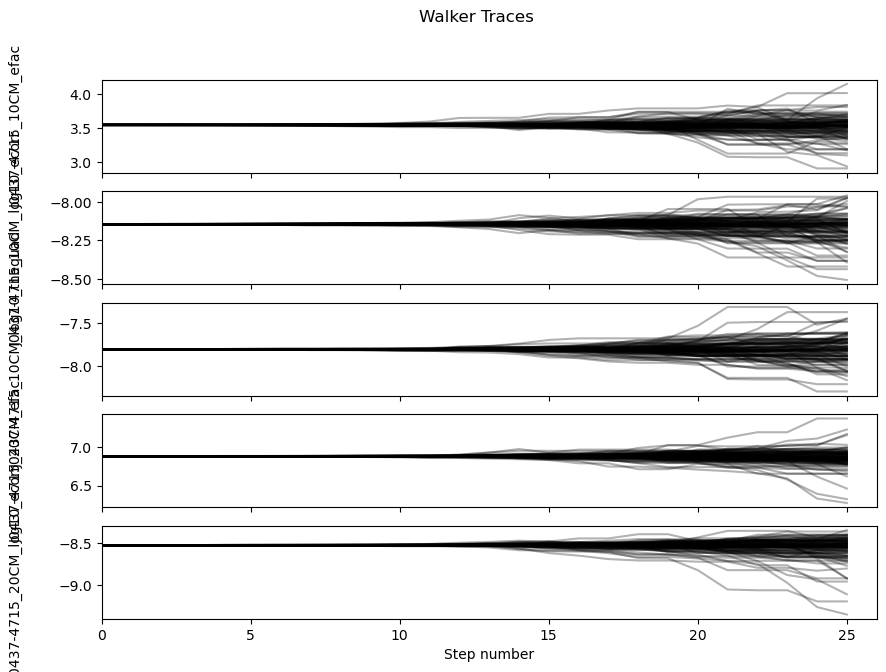

In [ ]:
import matplotlib.pyplot as plt 
%matplotlib inline

samples = sampler.get_chain()
# Plot the traces of the walkers for each parameter
fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
labels = pta[0].param_names
for i in range(5):
    ax = axes[i]
    # The shape of samples is (nsteps, nwalkers, ndim)
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("Step number")
plt.suptitle("Walker Traces")
plt.show()

In [ ]:
pta[0].param_names

['J0437-4715_10CM_efac',
 'J0437-4715_10CM_log10_ecorr',
 'J0437-4715_10CM_log10_tnequad',
 'J0437-4715_20CM_efac',
 'J0437-4715_20CM_log10_ecorr',
 'J0437-4715_20CM_log10_tnequad',
 'J0437-4715_40CM_efac',
 'J0437-4715_40CM_log10_ecorr',
 'J0437-4715_40CM_log10_tnequad',
 'J0437-4715_dm_gp_gamma',
 'J0437-4715_dm_gp_log10_A',
 'J0437-4715_dmexp_idx',
 'J0437-4715_dmexp_log10_Amp',
 'J0437-4715_dmexp_log10_tau',
 'J0437-4715_dmexp_t0',
 'J0437-4715_red_noise_gamma',
 'J0437-4715_red_noise_log10_A',
 'J0613-0200_10CM_efac',
 'J0613-0200_10CM_log10_ecorr',
 'J0613-0200_10CM_log10_tnequad',
 'J0613-0200_20CM_efac',
 'J0613-0200_20CM_log10_ecorr',
 'J0613-0200_20CM_log10_tnequad',
 'J0613-0200_40CM_efac',
 'J0613-0200_40CM_log10_ecorr',
 'J0613-0200_40CM_log10_tnequad',
 'J0613-0200_dm_s1yr_log10_Amp',
 'J0613-0200_dm_s1yr_phase',
 'J0613-0200_red_noise_gamma',
 'J0613-0200_red_noise_log10_A',
 'gamma_pol_x_10CM',
 'gamma_pol_x_20CM',
 'gamma_pol_x_40CM',
 'gamma_pol_y_10CM',
 'gamma_pol_y

Shape of flat samples after burn-in and thinning: (480, 48)


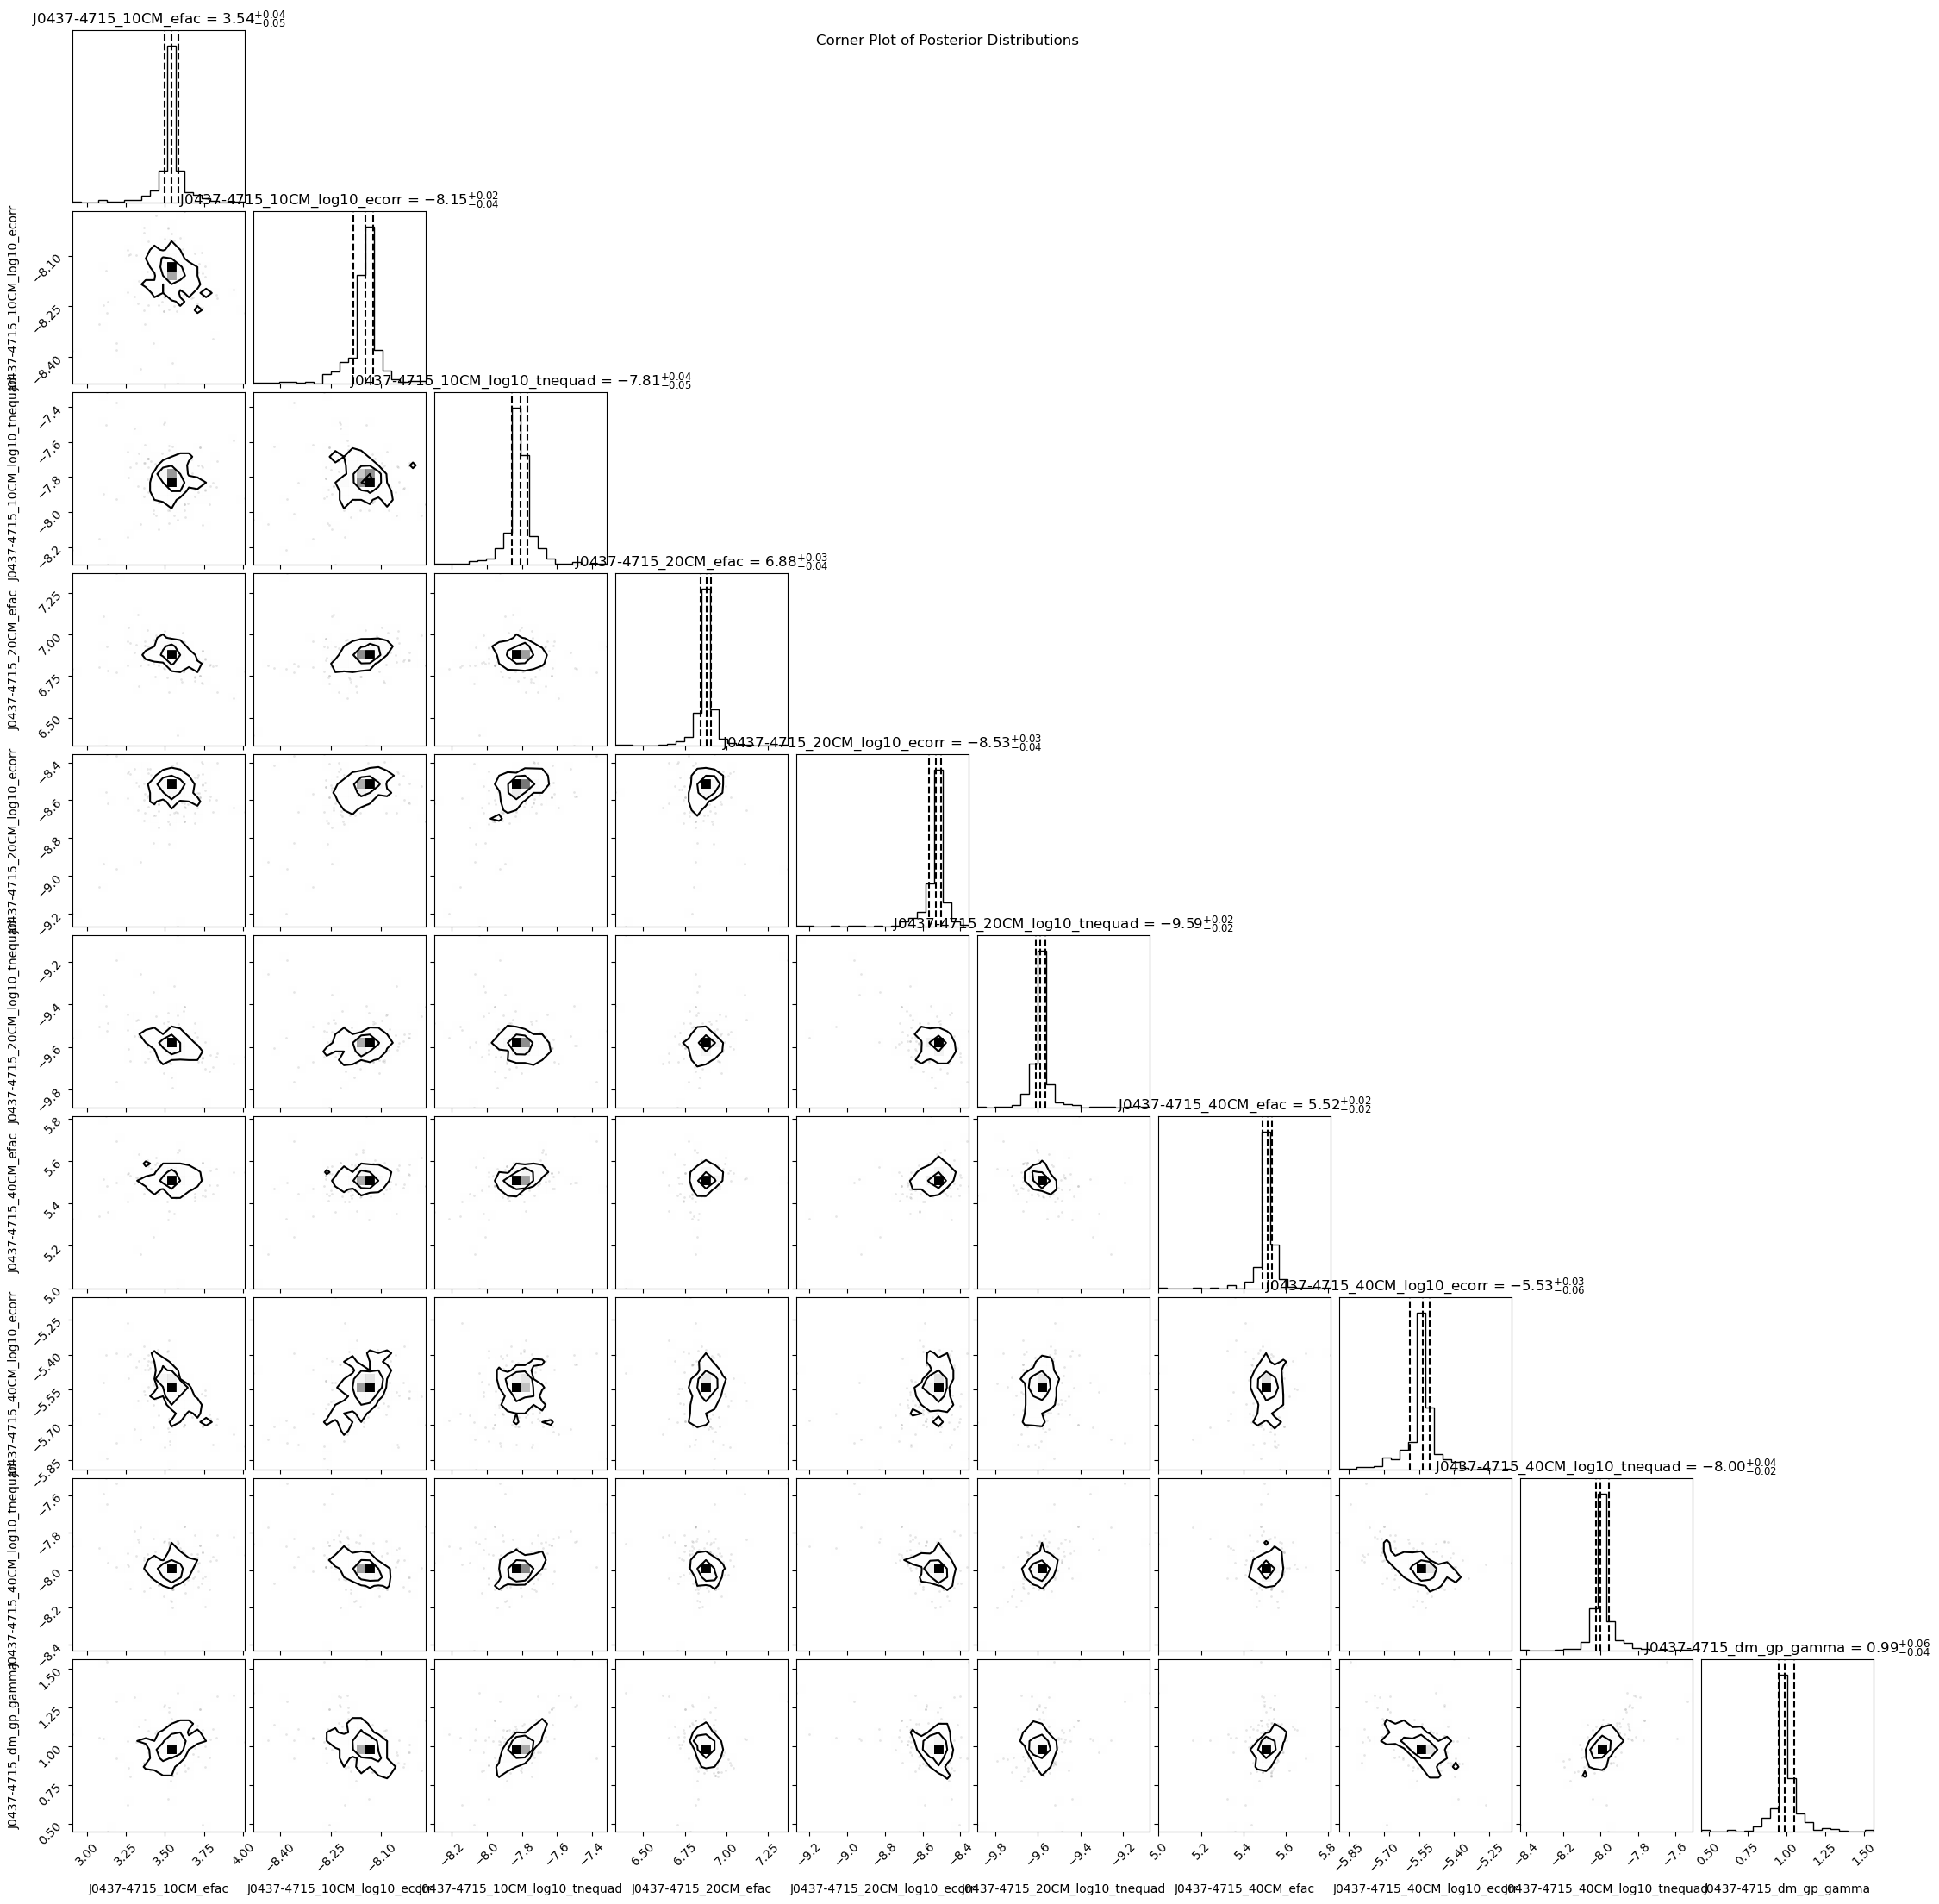

In [ ]:
import corner

burnin = 10
flat_samples = sampler.get_chain(discard=burnin, thin=3, flat=True)
print("Shape of flat samples after burn-in and thinning:", flat_samples.shape)

# Create a corner plot to visualize the posterior distributions
fig = corner.corner(
    flat_samples[:,:10], labels=labels, quantiles=[0.16, 0.5, 0.84], show_titles=True
)
plt.suptitle("Corner Plot of Posterior Distributions")
plt.show()